#  GC PSAR — Entradas, Salidas y Excursiones MAE/MFE
## Notebook B.02 del Hands-On: Masterclass de Diseño de Estrategias Cuantitativas

---

**Objetivo:** Implementar la entrada PSAR, comparar tipos de salida, calcular MAE/MFE, y calibrar stops/targets empíricos para el trend trading en Oro.

> *"La entrada solo decide cuántas veces aciertas; la salida decide cuánto ganas."*

| Slide | Concepto |
|:---:|---|
| 06 | Costo de cada condición |
| 07 | Expectancy (3 salidas) |
| 08 | Los 4 tipos de salida |
| 09 | MAE/MFE — Calibración empírica |

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import pandas_ta_classic as ta
import vectorbt as vbt
import warnings
warnings.filterwarnings('ignore')

import sys; sys.path.insert(0, '.')
from nb_style import *

---
## 1. Carga y Preparación del Dataset

In [8]:
section_header('CARGA DE DATOS @GC 5m → 1h', '')

df_5m = pd.read_csv('../@GC_5m.csv', parse_dates=['TimeStamp'])
df_5m.set_index('TimeStamp', inplace=True)
df_1h = df_5m.resample('1h', label='left').agg({
    'Open': 'first', 'High': 'max', 'Low': 'min', 'Close': 'last',
    'TotalVolume': 'sum'
}).dropna(subset=['Open']).copy()
df_1h.rename(columns={'TotalVolume': 'Volume'}, inplace=True)

# Sesiones y volatilidad
df_1h['dt_chi'] = df_1h.index.tz_convert('America/Chicago')
df_1h['Hour_chi'] = df_1h['dt_chi'].dt.hour
df_1h['Date_local'] = df_1h['dt_chi'].dt.date
h = df_1h['Hour_chi']
conds = [(h >= 17) | (h < 1), (h >= 1) & (h < 7), (h >= 7) & (h < 13)]
choices = ['1.Asia', '2.Europe', '3.US_RTH']
df_1h['Session'] = np.select(conds, choices, default='4.Post_RTH')
df_1h['Trading_Date'] = np.where(h >= 17,
    pd.Series(df_1h['Date_local'].values) + pd.Timedelta(days=1),
    df_1h['Date_local'].values)

# Volatilidad
df_rth = df_1h[df_1h['Session'] == '3.US_RTH'].copy()
daily = df_rth.groupby('Trading_Date').agg(
    d_High=('High', 'max'), d_Low=('Low', 'min'), d_Close=('Close', 'last')
).reset_index()
daily['prev_Close'] = daily['d_Close'].shift(1)
tr = np.maximum(daily['d_High'] - daily['d_Low'],
     np.maximum((daily['d_High'] - daily['prev_Close']).abs(),
                (daily['d_Low'] - daily['prev_Close']).abs()))
daily['ATR_14'] = tr.rolling(14).mean().shift(1)
daily['ATR_14_Pct'] = (daily['ATR_14'] / daily['prev_Close'] * 100)
daily['Vol_Regime'] = np.where(daily['ATR_14_Pct'] > daily['ATR_14_Pct'].median(), 'Alta Vol', 'Baja Vol')
vol_map = daily.set_index('Trading_Date')[['Vol_Regime', 'ATR_14']].to_dict()
df_1h['Vol_Regime'] = df_1h['Trading_Date'].map(vol_map['Vol_Regime'])
df_1h['ATR_14_daily'] = df_1h['Trading_Date'].map(vol_map['ATR_14'])
df_1h = df_1h.dropna(subset=['Vol_Regime', 'ATR_14_daily']).copy()

# PSAR óptimo (AF=0.005, MaxAF=0.15)
AF_OPT, MAXAF_OPT, THRESH = 0.005, 0.15, 24
psar = df_1h.ta.psar(af=AF_OPT, max_af=MAXAF_OPT)
bull = psar[f'PSARl_{AF_OPT}_{MAXAF_OPT}'].notnull()
streak_vals = []
s = 0
for v in bull.values:
    s = s + 1 if v else 0
    streak_vals.append(s)
df_1h['Streak'] = streak_vals
df_1h['Entry_Signal'] = df_1h['Streak'] == THRESH
col_s = f'PSARs_{AF_OPT}_{MAXAF_OPT}'
df_1h['Exit_Signal'] = psar[col_s].notnull() & (~psar[col_s].shift(1).notnull().fillna(False))

section_header('DATASET LISTO', '')
print(f'Barras 1h: {len(df_1h):,}')
print(f'Entradas detectadas (streak=={THRESH}): {df_1h["Entry_Signal"].sum():,}')


══════════════════════════════════════════════════════════════════════
  CARGA DE DATOS @GC 5m → 1h
══════════════════════════════════════════════════════════════════════


══════════════════════════════════════════════════════════════════════
  DATASET LISTO
══════════════════════════════════════════════════════════════════════

Barras 1h: 132,826
Entradas detectadas (streak==24): 1,301


---
## 2. Costo de Cada Condición — Filtros Progresivos (Slide 06)


══════════════════════════════════════════════════════════════════════
 📉 COSTO DE CADA CONDICIÓN
══════════════════════════════════════════════════════════════════════

Base: Todas las barras.......................  1301 trades
+ Solo US RTH................................   341 trades
+ Alta Volatilidad...........................   190 trades


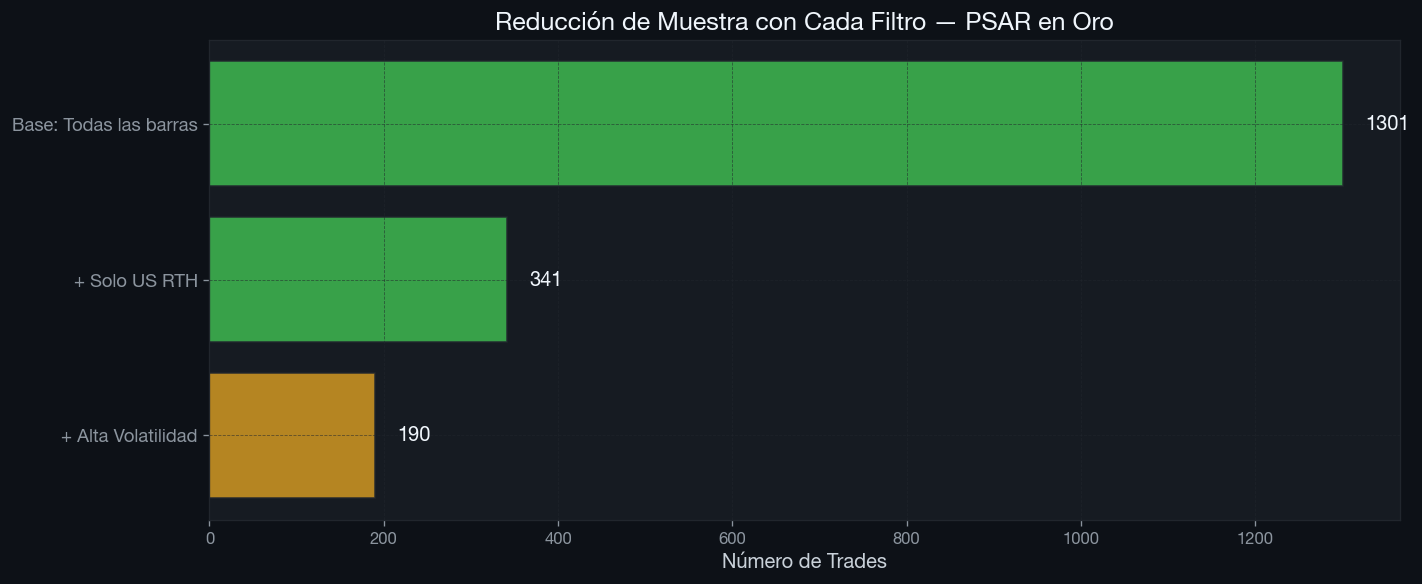

In [9]:
section_header('COSTO DE CADA CONDICIÓN', '📉')

def count_trades_psar(df, mask):
    df_sub = df[mask].copy()
    entry = df_sub['Entry_Signal']
    exit_s = df_sub['Exit_Signal']
    if entry.sum() == 0: return 0
    pf = vbt.Portfolio.from_signals(close=df_sub['Close'], entries=entry, exits=exit_s,
                                     init_cash=100000, fees=0.0001, freq='1h')
    return pf.trades.count()

filters = [
    ('Base: Todas las barras', pd.Series(True, index=df_1h.index)),
    ('+ Solo US RTH', df_1h['Session'] == '3.US_RTH'),
    ('+ Alta Volatilidad', (df_1h['Session'] == '3.US_RTH') & (df_1h['Vol_Regime'] == 'Alta Vol')),
]

trades_counts = []
for name, mask in filters:
    n = count_trades_psar(df_1h, mask)
    trades_counts.append((name, n))
    print(f'{name:.<45s} {n:>5} trades')

fig, ax = plt.subplots(figsize=(12, 5))
names = [t[0] for t in trades_counts]
counts = [t[1] for t in trades_counts]
colors_bar = [COLORS['green'] if c >= 200 else COLORS['orange'] if c >= 60 else COLORS['red'] for c in counts]
bars = ax.barh(range(len(names)-1, -1, -1), counts, color=colors_bar, alpha=0.85, edgecolor=COLORS['grid'])
for i, (bar, c) in enumerate(zip(bars, counts)):
    ax.text(c + max(counts)*0.02, len(names)-1-i, f'{c}', va='center', fontsize=12,
            color=COLORS['text_bright'], fontweight='bold')
ax.set_yticks(range(len(names)-1, -1, -1))
ax.set_yticklabels(names, fontsize=11)
ax.set_xlabel('Número de Trades')
ax.set_title('Reducción de Muestra con Cada Filtro — PSAR en Oro',
             fontsize=15, fontweight='bold', color=COLORS['text_bright'])
plt.tight_layout()
plt.show()

---
## 3. Tres Salidas, Una Entrada — Redistribución del Edge (Slide 07-08)


══════════════════════════════════════════════════════════════════════
  3 SALIDAS, 1 ENTRADA PSAR
══════════════════════════════════════════════════════════════════════

Trades generados: 1301
Duración media: 24h | Mediana: 20h

Reversa PSAR.................. WR=38.3%  PF=1.38  E[R]=0.096  Total=124.2R
Tiempo (24h).................. WR=50.7%  PF=1.10  E[R]=0.031  Total=40.0R
SL/TP (1:2)................... WR=38.4%  PF=1.30  E[R]=0.072  Total=93.5R


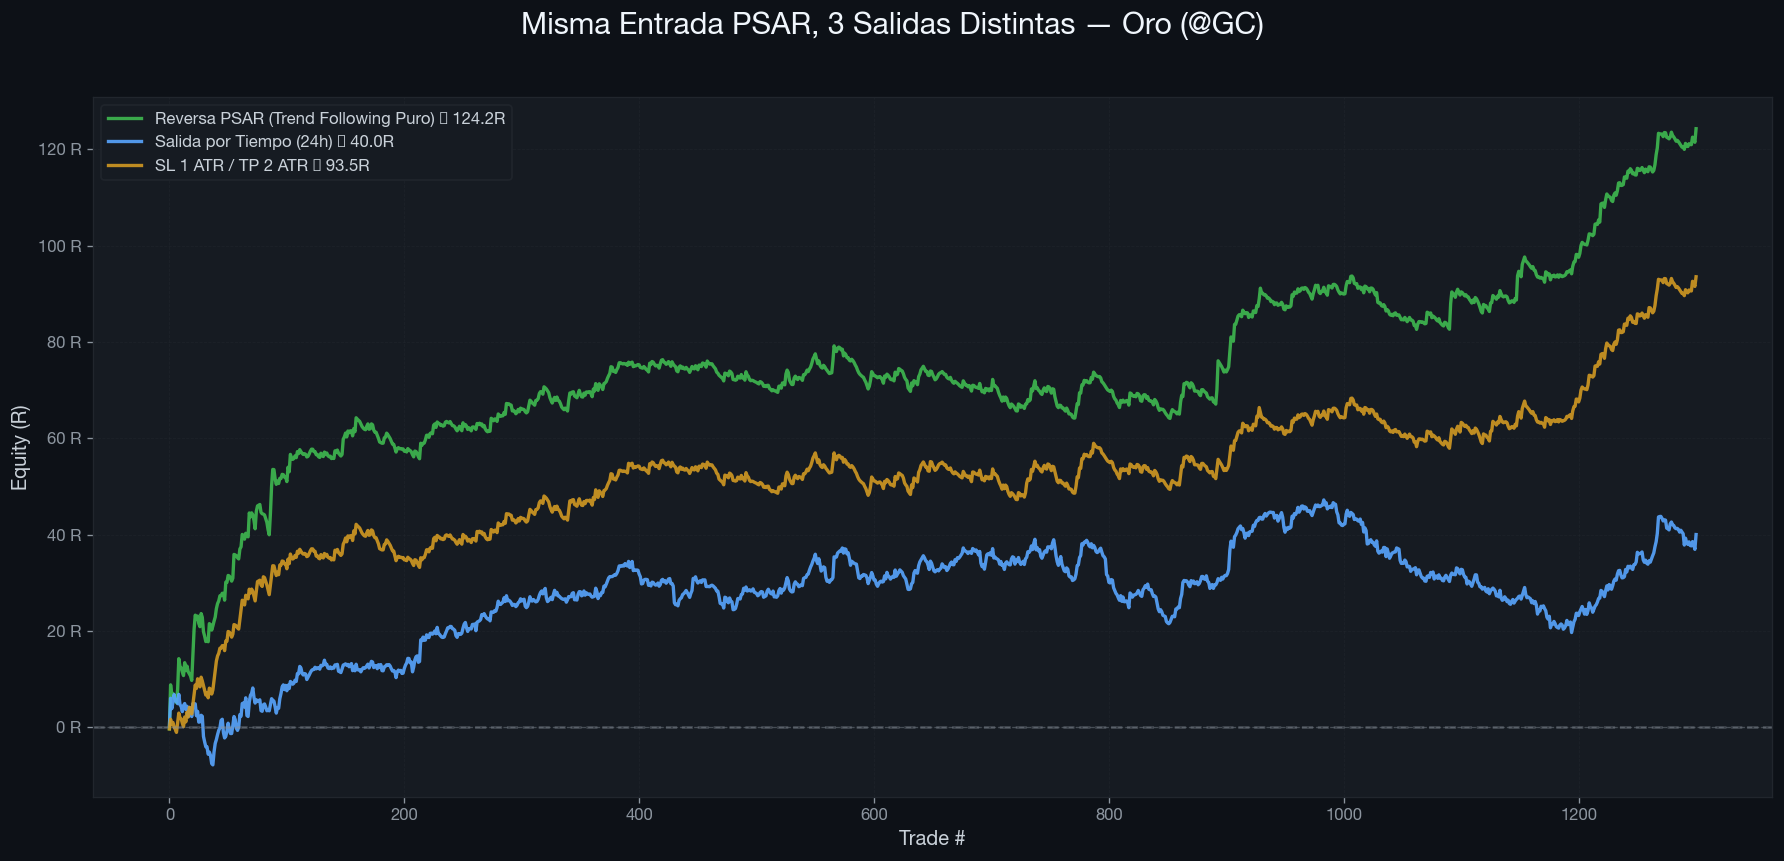

In [10]:
# ═══ 3 SALIDAS COMPARADAS ═══
section_header('3 SALIDAS, 1 ENTRADA PSAR', '')

entries_idx = df_1h.index[df_1h['Entry_Signal']]
trades_detail = []

for entry_time in entries_idx:
    entry_price = df_1h.loc[entry_time, 'Close']
    atr = df_1h.loc[entry_time, 'ATR_14_daily']
    if pd.isna(atr) or atr <= 0:
        continue

    future = df_1h.loc[entry_time:].iloc[1:]

    # Salida 1: Reversa PSAR
    exit_psar = future[future['Exit_Signal']]
    if len(exit_psar) == 0:
        continue
    exit_time_psar = exit_psar.index[0]
    exit_price_psar = df_1h.loc[exit_time_psar, 'Close']
    ret_psar = (exit_price_psar - entry_price) / atr

    # Salida 2: Tiempo (24h)
    if len(future) >= 24:
        exit_price_time = future.iloc[23]['Close']
        ret_time = (exit_price_time - entry_price) / atr
    else:
        ret_time = ret_psar

    # Salida 3: SL/TP fijo (1 ATR SL, 2 ATR TP)
    sl_price = entry_price - 1.0 * atr
    tp_price = entry_price + 2.0 * atr
    ret_sltp = ret_psar
    trade_bars = future.loc[:exit_time_psar]
    if len(trade_bars) > 0:
        hit_sl = (trade_bars['Low'] <= sl_price).any()
        hit_tp = (trade_bars['High'] >= tp_price).any()
        if hit_tp and not hit_sl:
            ret_sltp = 2.0
        elif hit_sl:
            ret_sltp = -1.0

    # MAE/MFE
    mae, mfe = 0.0, 0.0
    if len(trade_bars) > 0:
        mae = (trade_bars['Low'].min() - entry_price) / atr
        mfe = (trade_bars['High'].max() - entry_price) / atr

    trades_detail.append({
        'Entry_Time': entry_time, 'Entry_Price': entry_price, 'ATR': atr,
        'Ret_PSAR': ret_psar, 'Ret_Time': ret_time, 'Ret_SLTP': ret_sltp,
        'MAE_ATR': mae, 'MFE_ATR': mfe,
        'Duration_Hours': len(trade_bars),
        'Winner_PSAR': ret_psar > 0
    })

df_trades = pd.DataFrame(trades_detail)
print(f'Trades generados: {len(df_trades)}')
print(f'Duración media: {df_trades["Duration_Hours"].mean():.0f}h | Mediana: {df_trades["Duration_Hours"].median():.0f}h')

print()
for col, label in [('Ret_PSAR', 'Reversa PSAR'), ('Ret_Time', 'Tiempo (24h)'), ('Ret_SLTP', 'SL/TP (1:2)')]:
    r = df_trades[col].values
    wr = (r > 0).mean() * 100
    pf = r[r > 0].sum() / abs(r[r < 0].sum()) if (r < 0).any() and r[r < 0].sum() != 0 else np.inf
    print(f'{label:.<30s} WR={wr:.1f}%  PF={pf:.2f}  E[R]={r.mean():.3f}  Total={r.sum():.1f}R')

# ═══ GRÁFICO: 3 EQUITY CURVES ═══
fig, ax = plt.subplots(figsize=(15, 7))
fig.suptitle('Misma Entrada PSAR, 3 Salidas Distintas — Oro (@GC)',
             fontsize=18, fontweight='bold', color=COLORS['text_bright'], y=1.02)

for col, color, label in [
    ('Ret_PSAR', COLORS['green'], 'Reversa PSAR (Trend Following Puro)'),
    ('Ret_Time', COLORS['blue'], 'Salida por Tiempo (24h)'),
    ('Ret_SLTP', COLORS['orange'], 'SL 1 ATR / TP 2 ATR'),
]:
    cum = np.cumsum(df_trades[col].values)
    ax.plot(cum, color=color, lw=2, label=f'{label} → {cum[-1]:.1f}R', alpha=0.9)

ax.axhline(0, color=COLORS['text_dim'], linestyle='--', alpha=0.3)
style_equity_curve(ax, ylabel='Equity (R)')
ax.set_xlabel('Trade #')
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f R'))
plt.tight_layout()
plt.show()

---
## 4. Retorno por Duración del Trade — ¿Cuánto Dura el Edge?

Cada trade PSAR tiene una duración distinta (el SAR puede tardar horas o semanas en revertir). Veamos cómo se distribuye el retorno según cuánto dura la posición.

> *¿Los trades largos ganan más, o hay un punto donde el edge se agota?*


══════════════════════════════════════════════════════════════════════
 ⏱️ RETORNO vs DURACIÓN DE LA POSICIÓN
══════════════════════════════════════════════════════════════════════



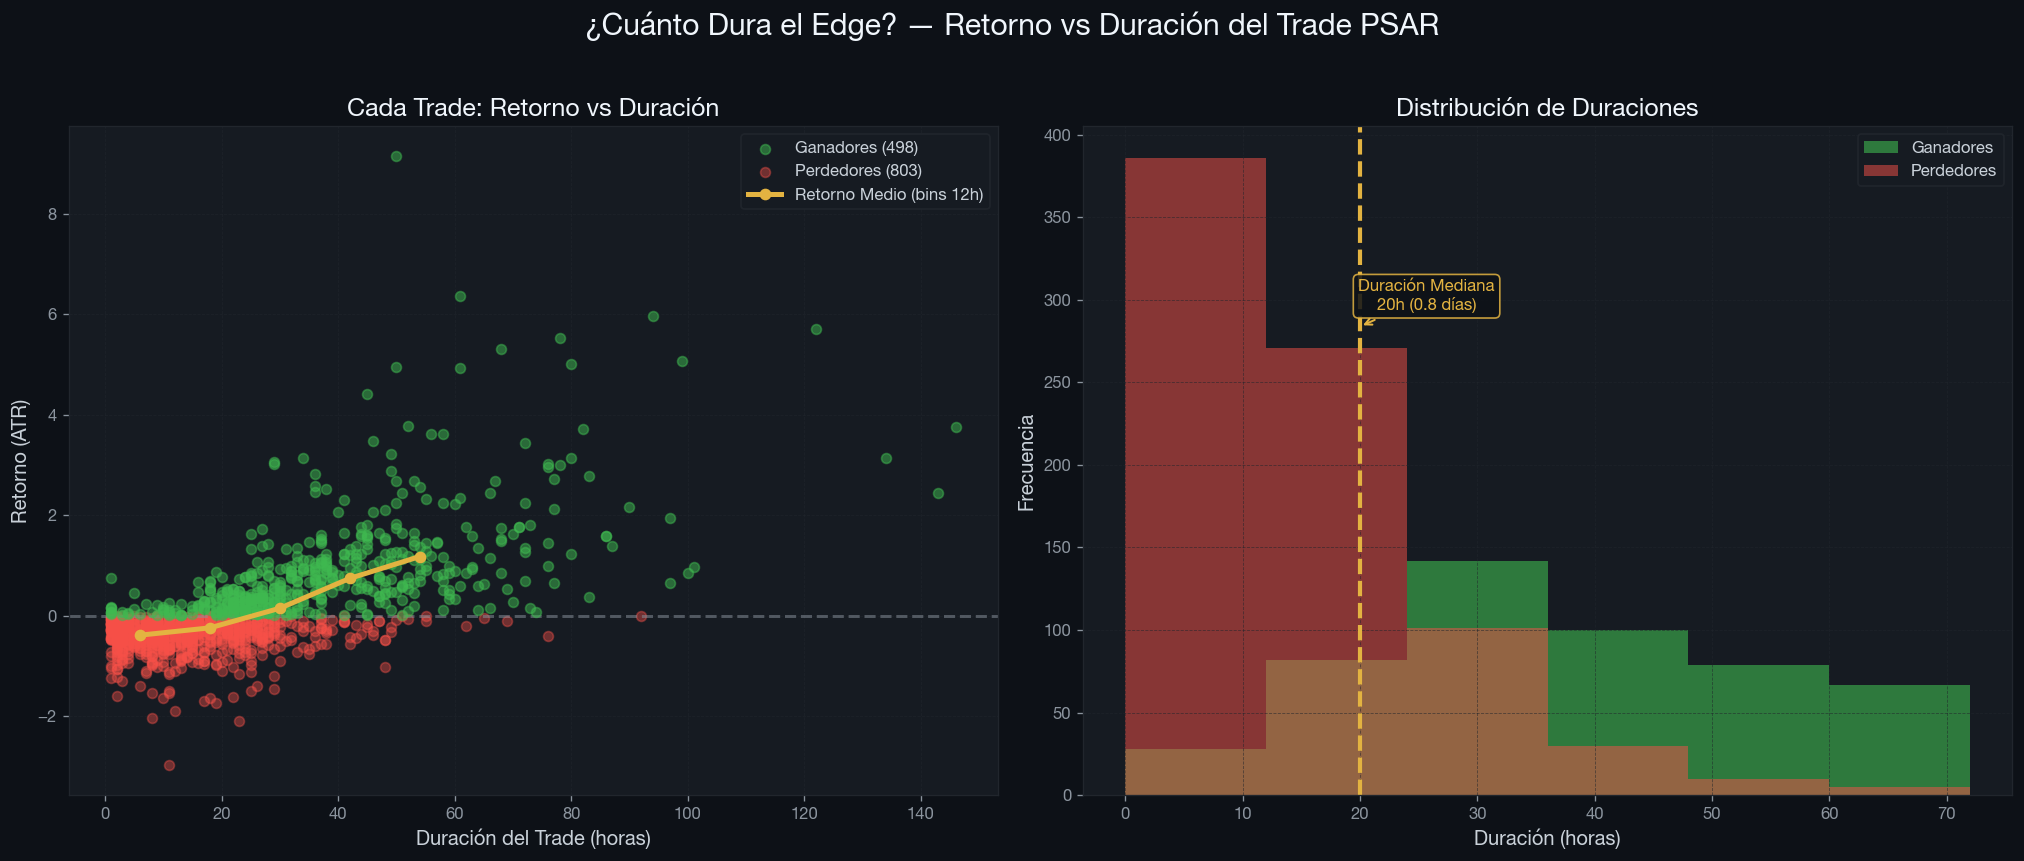


══════════════════════════════════════════════════════════════════════
  RETORNO POR BANDAS DE DURACIÓN
══════════════════════════════════════════════════════════════════════

Banda....................     N     WR%    E[R]  Ret Total
────────────────────────────────────────────────────────────
<1 día...................   767   14.3%  -0.32R    -247.8R
1-3 días.................   495   70.9%  +0.58R    +285.5R
3-7 días.................    39   94.9%  +2.22R     +86.5R


In [11]:
# ═══ RETORNO vs DURACIÓN DE LA POSICIÓN ═══
section_header('RETORNO vs DURACIÓN DE LA POSICIÓN', '⏱️')

winners = df_trades[df_trades['Winner_PSAR']]
losers = df_trades[~df_trades['Winner_PSAR']]

fig, axes = plt.subplots(1, 2, figsize=(17, 7))
fig.suptitle('¿Cuánto Dura el Edge? — Retorno vs Duración del Trade PSAR',
             fontsize=18, fontweight='bold', color=COLORS['text_bright'], y=1.02)

# ─── Panel A: Scatter retorno vs duración ───
ax = axes[0]
ax.scatter(winners['Duration_Hours'], winners['Ret_PSAR'],
           c=COLORS['green'], alpha=0.5, s=35, label=f'Ganadores ({len(winners)})', zorder=3)
ax.scatter(losers['Duration_Hours'], losers['Ret_PSAR'],
           c=COLORS['red'], alpha=0.4, s=35, label=f'Perdedores ({len(losers)})', zorder=2)
ax.axhline(0, color=COLORS['text_dim'], linestyle='--', alpha=0.5)

# Línea de tendencia por bins de 12h
dur_max = df_trades['Duration_Hours'].quantile(0.95)
dur_bins = np.arange(0, dur_max, 12)
means_by_dur = []
for i in range(len(dur_bins) - 1):
    mask = (df_trades['Duration_Hours'] >= dur_bins[i]) & (df_trades['Duration_Hours'] < dur_bins[i + 1])
    sub = df_trades[mask]
    if len(sub) >= 3:
        means_by_dur.append(((dur_bins[i] + dur_bins[i + 1]) / 2, sub['Ret_PSAR'].mean()))

if means_by_dur:
    mx, my = zip(*means_by_dur)
    ax.plot(mx, my, color=COLORS['yellow'], lw=3, marker='o', markersize=6,
            label='Retorno Medio (bins 12h)', zorder=5)

ax.set_xlabel('Duración del Trade (horas)', fontsize=12)
ax.set_ylabel('Retorno (ATR)', fontsize=12)
ax.set_title('Cada Trade: Retorno vs Duración', color=COLORS['text_bright'])
ax.legend(fontsize=10, loc='upper right')

# ─── Panel B: Histograma de duración ───
ax = axes[1]
max_dur = int(df_trades['Duration_Hours'].quantile(0.95))
bins_hist = np.arange(0, max_dur + 12, 12)

ax.hist(winners['Duration_Hours'].clip(upper=max_dur), bins=bins_hist,
        color=COLORS['green'], alpha=0.6, edgecolor='none', label='Ganadores')
ax.hist(losers['Duration_Hours'].clip(upper=max_dur), bins=bins_hist,
        color=COLORS['red'], alpha=0.5, edgecolor='none', label='Perdedores')

med_dur = df_trades['Duration_Hours'].median()
ax.axvline(med_dur, color=COLORS['yellow'], lw=2.5, linestyle='--')
annotate_point(ax, med_dur, ax.get_ylim()[1] * 0.7 if ax.get_ylim()[1] > 0 else 5,
               f'Duración Mediana\n{med_dur:.0f}h ({med_dur / 24:.1f} días)',
               color=COLORS['yellow'], offset=(40, 10))

ax.set_xlabel('Duración (horas)', fontsize=12)
ax.set_ylabel('Frecuencia')
ax.set_title('Distribución de Duraciones', color=COLORS['text_bright'])
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

# ─── Tabla por bandas ───
section_header('RETORNO POR BANDAS DE DURACIÓN', '')
duration_bands = [(0, 24, '<1 día'), (24, 72, '1-3 días'), (72, 168, '3-7 días'),
                  (168, 336, '1-2 semanas'), (336, 9999, '>2 semanas')]
print(f'{"Banda":.<25s} {"N":>5s} {"WR%":>7s} {"E[R]":>7s} {"Ret Total":>10s}')
print('─' * 60)
for lo, hi, label in duration_bands:
    sub = df_trades[(df_trades['Duration_Hours'] >= lo) & (df_trades['Duration_Hours'] < hi)]
    if len(sub) < 2:
        continue
    wr = (sub['Ret_PSAR'] > 0).mean() * 100
    er = sub['Ret_PSAR'].mean()
    total = sub['Ret_PSAR'].sum()
    print(f'{label:.<25s} {len(sub):>5d} {wr:>6.1f}% {er:>+6.2f}R {total:>+9.1f}R')

---
## 5.  Excursiones MAE y MFE — Calibración Empírica del Stop y Target (Slide 09)

En vez de adivinar el stop y el target, preguntamos directamente a los datos:

- **MAE:** ¿Cuánto cayó el trade en tu contra ANTES de terminar ganando?
- **MFE:** ¿Cuánto llegó a estar A FAVOR el trade?

### La regla:
> Si el **95% de los ganadores** nunca cayó más de X ATR → **pon el stop en X**  
> Si la **mediana de ganadores** alcanzó Y ATR a favor → **pon el target en Y**


══════════════════════════════════════════════════════════════════════
  CALIBRACIÓN EMPÍRICA: MAE & MFE
══════════════════════════════════════════════════════════════════════



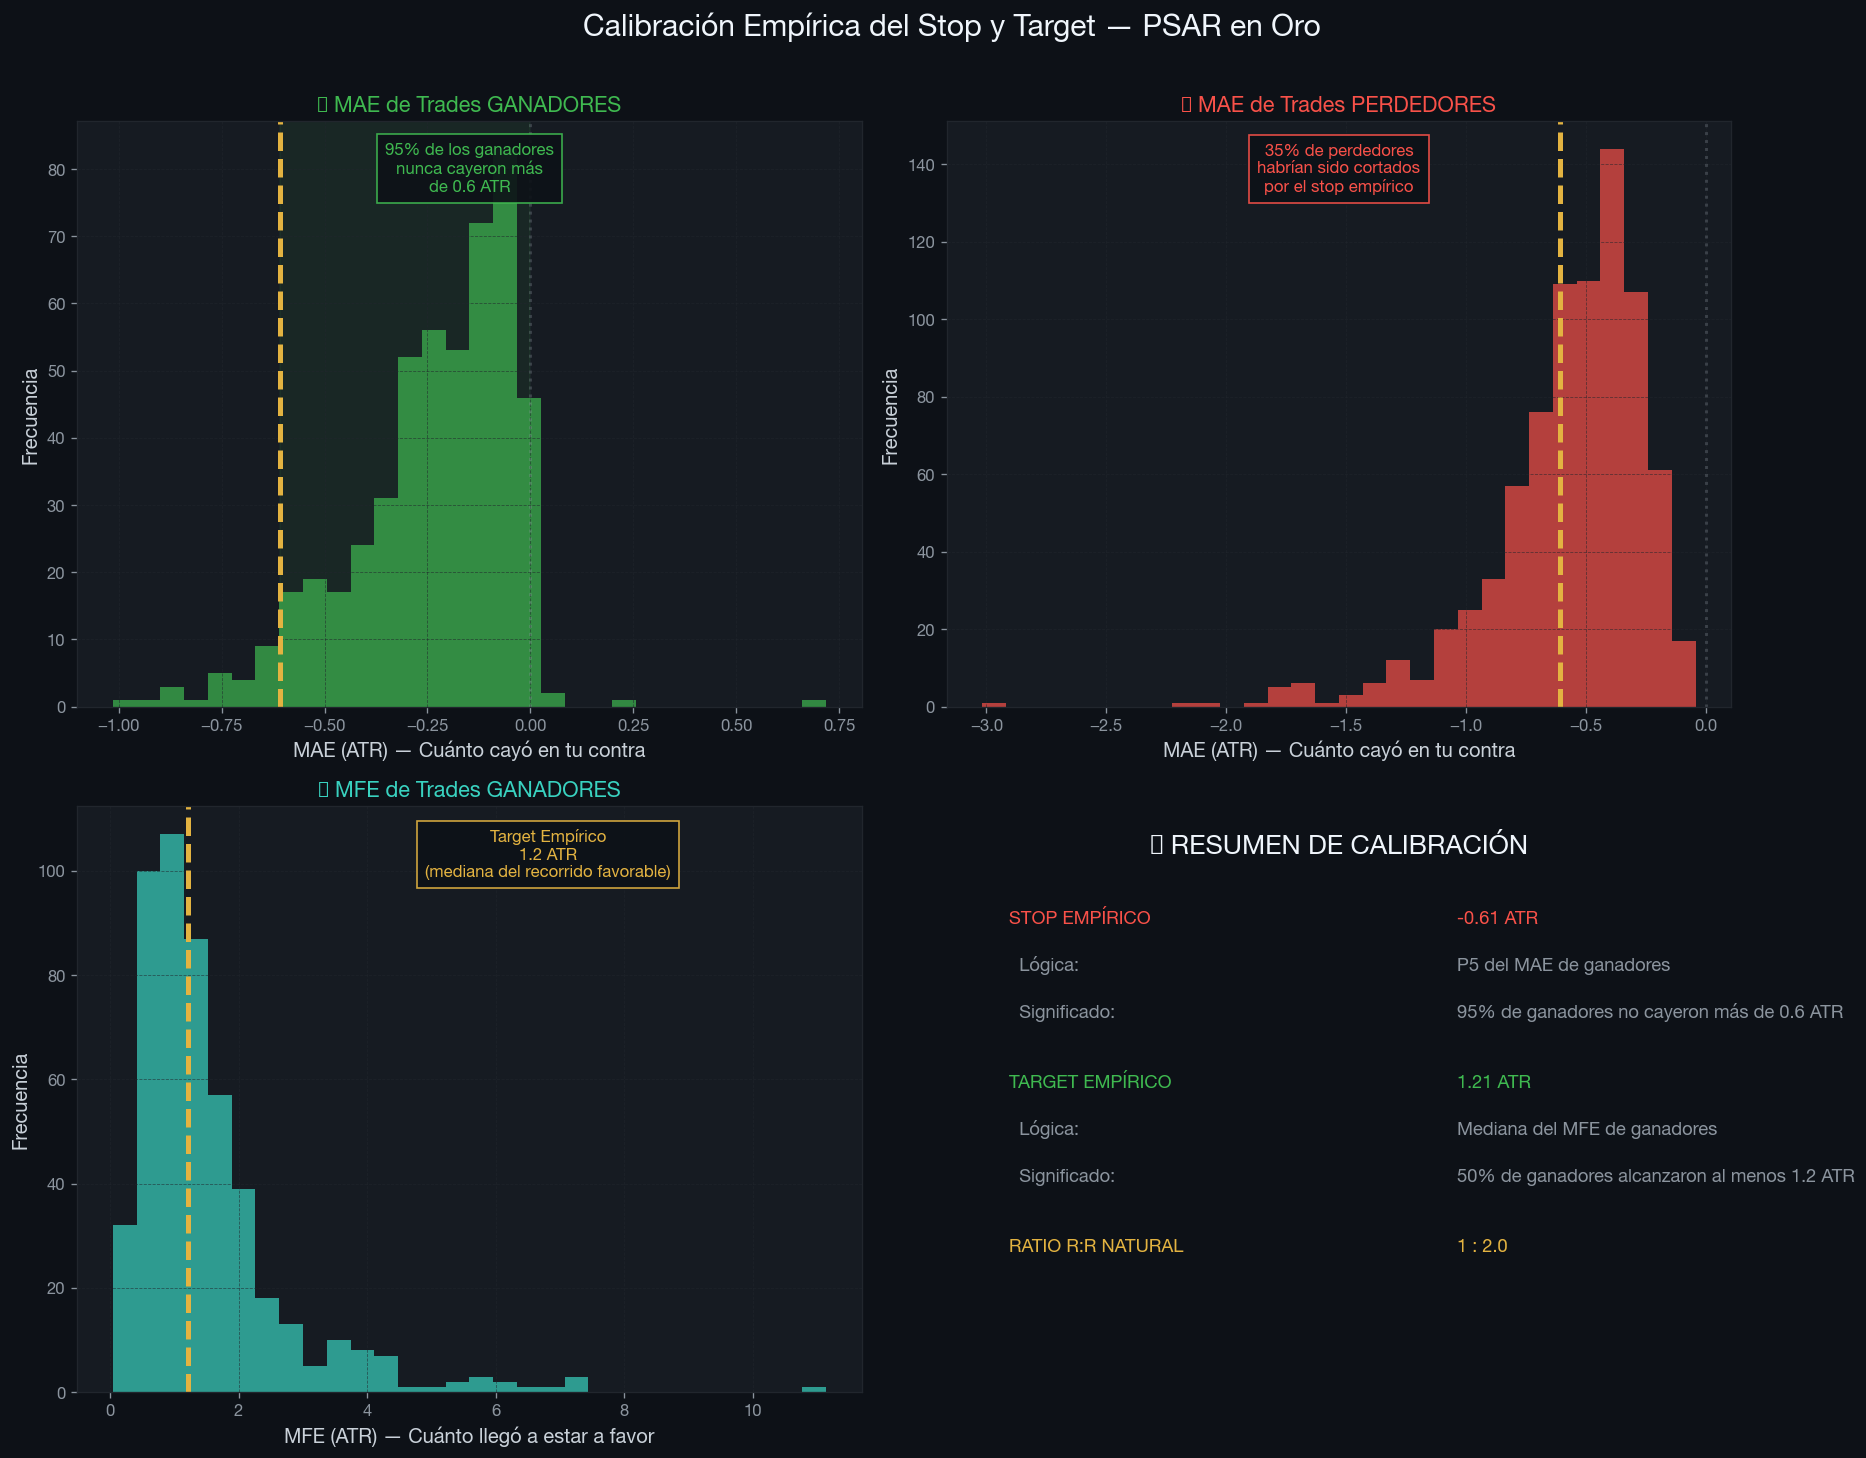


══════════════════════════════════════════════════════════════════════
  CALIBRACIÓN COMPLETA
══════════════════════════════════════════════════════════════════════

STOP:   -0.61 ATR — Protege el 95% de los ganadores
TARGET: 1.21 ATR — Captura la mediana del recorrido favorable
RATIO:  1 : 2.0 — Riesgo/Beneficio natural de la estrategia


In [12]:
# ═══ MAE/MFE — GRÁFICOS SIMPLIFICADOS ═══
section_header('CALIBRACIÓN EMPÍRICA: MAE & MFE', '')

winners = df_trades[df_trades['Winner_PSAR']]
losers = df_trades[~df_trades['Winner_PSAR']]

# Stop empírico: P5 del MAE de ganadores
stop_emp = winners['MAE_ATR'].quantile(0.05)
# Target empírico: Mediana del MFE de ganadores
target_emp = winners['MFE_ATR'].median()

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Calibración Empírica del Stop y Target — PSAR en Oro',
             fontsize=18, fontweight='bold', color=COLORS['text_bright'], y=1.01)

# ─── Panel A: MAE de Ganadores ───
ax = axes[0, 0]
ax.hist(winners['MAE_ATR'].values, bins=30, color=COLORS['green'], alpha=0.7, edgecolor='none')
ax.axvline(stop_emp, color=COLORS['yellow'], lw=3, linestyle='--')
ax.axvline(0, color=COLORS['text_dim'], linestyle=':', alpha=0.3)
ax.axvspan(stop_emp, 0, color=COLORS['green'], alpha=0.08)
ax.text(0.5, 0.88, f'95% de los ganadores\nnunca cayeron más\nde {abs(stop_emp):.1f} ATR',
        fontsize=10, color=COLORS['green'], fontweight='bold', ha='center',
        transform=ax.transAxes,
        bbox=dict(facecolor=COLORS['bg'], edgecolor=COLORS['green'], alpha=0.9, pad=5))
ax.set_xlabel('MAE (ATR) — Cuánto cayó en tu contra')
ax.set_ylabel('Frecuencia')
ax.set_title(' MAE de Trades GANADORES', color=COLORS['green'], fontsize=13)

# ─── Panel B: MAE de Perdedores ───
ax = axes[0, 1]
ax.hist(losers['MAE_ATR'].values, bins=30, color=COLORS['red'], alpha=0.7, edgecolor='none')
ax.axvline(stop_emp, color=COLORS['yellow'], lw=3, linestyle='--')
ax.axvline(0, color=COLORS['text_dim'], linestyle=':', alpha=0.3)
if len(losers) > 0:
    pct_cut = (losers['MAE_ATR'] < stop_emp).mean() * 100
    ax.text(0.5, 0.88, f'{pct_cut:.0f}% de perdedores\nhabrían sido cortados\npor el stop empírico',
            fontsize=10, color=COLORS['red'], fontweight='bold', ha='center',
            transform=ax.transAxes,
            bbox=dict(facecolor=COLORS['bg'], edgecolor=COLORS['red'], alpha=0.9, pad=5))
ax.set_xlabel('MAE (ATR) — Cuánto cayó en tu contra')
ax.set_ylabel('Frecuencia')
ax.set_title(' MAE de Trades PERDEDORES', color=COLORS['red'], fontsize=13)

# ─── Panel C: MFE de Ganadores ───
ax = axes[1, 0]
ax.hist(winners['MFE_ATR'].values, bins=30, color=COLORS['cyan'], alpha=0.7, edgecolor='none')
ax.axvline(target_emp, color=COLORS['yellow'], lw=3, linestyle='--')
ax.text(0.6, 0.88, f'Target Empírico\n{target_emp:.1f} ATR\n(mediana del recorrido favorable)',
        fontsize=10, color=COLORS['yellow'], fontweight='bold', ha='center',
        transform=ax.transAxes,
        bbox=dict(facecolor=COLORS['bg'], edgecolor=COLORS['yellow'], alpha=0.9, pad=5))
ax.set_xlabel('MFE (ATR) — Cuánto llegó a estar a favor')
ax.set_ylabel('Frecuencia')
ax.set_title(' MFE de Trades GANADORES', color=COLORS['cyan'], fontsize=13)

# ─── Panel D: Resumen ───
ax = axes[1, 1]
ax.axis('off')
ax.set_facecolor(COLORS['bg_card'])

ratio = abs(target_emp / stop_emp) if stop_emp != 0 else 0

ax.text(0.5, 0.92, ' RESUMEN DE CALIBRACIÓN', fontsize=16, fontweight='bold',
        color=COLORS['text_bright'], ha='center', transform=ax.transAxes)

info = [
    (0.80, 'STOP EMPÍRICO', f'{stop_emp:.2f} ATR', COLORS['red']),
    (0.72, '  Lógica:', 'P5 del MAE de ganadores', COLORS['text_dim']),
    (0.64, '  Significado:', f'95% de ganadores no cayeron más de {abs(stop_emp):.1f} ATR', COLORS['text_dim']),
    (0.52, 'TARGET EMPÍRICO', f'{target_emp:.2f} ATR', COLORS['green']),
    (0.44, '  Lógica:', 'Mediana del MFE de ganadores', COLORS['text_dim']),
    (0.36, '  Significado:', f'50% de ganadores alcanzaron al menos {target_emp:.1f} ATR', COLORS['text_dim']),
    (0.24, 'RATIO R:R NATURAL', f'1 : {ratio:.1f}', COLORS['yellow']),
]
for y, label, value, color in info:
    ax.text(0.08, y, label, fontsize=11, color=color, fontweight='bold', transform=ax.transAxes)
    ax.text(0.65, y, value, fontsize=11, color=color, fontweight='bold', transform=ax.transAxes)

plt.tight_layout()
plt.show()

section_header('CALIBRACIÓN COMPLETA', '')
print(f'STOP:   {stop_emp:.2f} ATR — Protege el 95% de los ganadores')
print(f'TARGET: {target_emp:.2f} ATR — Captura la mediana del recorrido favorable')
print(f'RATIO:  1 : {ratio:.1f} — Riesgo/Beneficio natural de la estrategia')

---
## 6. Resumen

### Lo que aprendimos:
- Las 3 salidas producen resultados distintos con la misma entrada PSAR
- Los trades más largos no siempre son más rentables — hay un sweet spot
- El stop empírico protege el 95% de los ganadores sin cortarlos por ruido
- El target empírico captura la mediana del recorrido favorable real

> ⏭️ **Siguiente: Notebook B.03** — Optimización, Sizing y Validación OOS